In [36]:
from langchain_ollama import OllamaLLM
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="minimax-m3:cloud",
    temperature=0
)

In [37]:
from langchain_core.messages import BaseMessage,HumanMessage,SystemMessage,AIMessage
from langgraph.graph import END,MessageGraph,StateGraph
from typing import List,Sequence
from langchain_core.prompts import ChatPromptTemplate,MessagesPlaceholder

#### Web search tool for temperature of city

In [ ]:
import warnings 
warnings.filterwarnings('ignore')

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.tools import tool
import os
import json
os.environ["TAVILY_API_KEY"] = "your api key"

# Initialize the Tavily search tool
search = TavilySearchResults()

@tool
def search_tool(query: str):
    """
    Search the web for information using Tavily API.

    :param query: The search query string
    :return: Search results related to the query
    """
    return search.invoke(query)

In [66]:
print(f'{search_tool.name,search_tool.description}')

('search_tool', 'Search the web for information using Tavily API.\n\n:param query: The search query string\n:return: Search results related to the query')


In [39]:
result=search_tool.invoke("what is the weather in kathmandu today")
print(result[1]['title'])

Weather - Kathmandu - 14-Day Forecast & Rain | Ventusky


#### Clothing Recommendation Tool

In [40]:
@tool
def recommend_clothing(weather: str)->str:
    """
    Returns a clothing recommendation based on the provided weather description.

    This function examines the input string for specific keywords or temperature indicators 
    (e.g., "snow", "freezing", "rain", "85°F") to suggest appropriate attire. It handles 
    common weather conditions like snow, rain, heat, and cold by providing simple and practical 
    clothing advice.

    :param weather: A brief description of the weather (e.g., "Overcast, 64.9°F")
    :return: A string with clothing recommendations suitable for the weather
    """
    weather = weather.lower()
    if "snow" in weather or "freezing" in weather:
        return "Wear a heavy coat, gloves, and boots."
    elif "rain" in weather or "wet" in weather:
        return "Bring a raincoat and waterproof shoes."
    elif "hot" in weather or "85" in weather:
        return "T-shirt, shorts, and sunscreen recommended."
    elif "cold" in weather or "50" in weather:
        return "Wear a warm jacket or sweater."
    else:
        return "A light jacket should be fine."
    
    


In [41]:
result=recommend_clothing.invoke(result[1]['title'])
print(result)

Bring a raincoat and waterproof shoes.


#### Creating the Tool Registry

In [42]:
tools=[search_tool,recommend_clothing]
tools_by_name={tool.name:tool for tool in tools}

#### creating the system prompt

In [43]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage,SystemMessage

chat_prompt = ChatPromptTemplate.from_messages([
    ("system", """
You are a helpful AI assistant that thinks step-by-step and uses tools when needed.

When responding to queries:
1. First, think about what information you need
2. Use available tools if you need current data or specific capabilities  
3. Provide clear, helpful responses based on your reasoning and any tool results

Always explain your thinking process to help users understand your approach.
"""),
    MessagesPlaceholder(variable_name="scratch_pad")
])

#### Binding tools to the model

In [44]:
model_react=chat_prompt | llm.bind_tools(tools)

#### Defining the agent state

In [45]:
from typing import (Annotated,Sequence,TypedDict)
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
class AgentState(TypedDict):
    """ The state of the agent"""
    messages:Annotated[Sequence[BaseMessage],add_messages]

**Key Concepts:**
- **State**: Contains the conversation history and context.
- **Reducer**: `add_messages` automatically handles adding new messages to the conversation.
- **Type Safety**: TypedDict ensures our state structure is well-defined.


#### Demonstrating State management

In [46]:
# example conversational flow 
state: AgentState={
    'messages':[]
}

# append the messages using the reducer property

state['messages'] =add_messages(state['messages'],[HumanMessage(content='Hi')])
print("After greeting",state['messages'])

# add another messages

state['messages']=add_messages(state['messages'],[HumanMessage(content='what is the weather of siraha,Nepal')])
print(f'After question',state)

After greeting [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='59c13a29-f6af-4642-9cde-72f92b6fd320')]
After question {'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='59c13a29-f6af-4642-9cde-72f92b6fd320'), HumanMessage(content='what is the weather of siraha,Nepal', additional_kwargs={}, response_metadata={}, id='9e4aa13f-6b88-4d2a-9c48-b9b68d4f0a2d')]}


#### This demonstrate how the state accumulates context over the conversation

#### Manual ReAct Execution (understanding the flow)

##### Step 1: Initial Query Processing

In [47]:
dummy_state: AgentState={
    'messages': [HumanMessage("what is the weather like in Siraha,Nepal and what should i wear based on the temperature ")]
}

response=model_react.invoke({'scratch_pad':dummy_state['messages']})

dummy_state['messages']=add_messages(dummy_state['messages'],[response])

**What Happens Here:**
1. The user asks a complex question requiring current data.
2. The model analyzes the query and realizes it needs to search for weather information.
3. The model generates a tool call for the search.


##### Step 2: Tool Execution

In [48]:
tool_call = response.tool_calls[-1]
print("Tool call:", tool_call)

tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
print("Tool result preview:", tool_result[0]['title'])

tool_message = ToolMessage(
    content=json.dumps(tool_result),
    name=tool_call["name"],
    tool_call_id=tool_call["id"]
)
dummy_state["messages"] = add_messages(dummy_state["messages"], [tool_message])

Tool call: {'name': 'search_tool', 'args': {'query': 'current weather in Siraha Nepal temperature'}, 'id': 'e0ced717-c7d6-4056-9d31-de16f8cbb702', 'type': 'tool_call'}
Tool result preview: Siraha Weather - 7, 10 & 14 Day Weather Forecast - Nepal


**What Happens Here:**
1. Extract the tool call from the model's response.
2. Execute the tool using the specified arguments.
3. Create a ToolMessage containing the results.
4. Add the tool result to the conversation state.


##### Step 3: Processing Results and Next Action

In [49]:
response = model_react.invoke({"scratch_pad": dummy_state["messages"]})
dummy_state['messages'] = add_messages(dummy_state['messages'], [response])

# check if the model wants to use another tool
if response.tool_calls:
    tool_call = response.tool_calls[0]
    tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
    tool_message = ToolMessage(
        content=json.dumps(tool_result),
        name=tool_call["name"],
        tool_call_id=tool_call["id"]
    )
    dummy_state['messages'] = add_messages(dummy_state['messages'], [tool_message])

**What Happens Here:**
1. The model processes the search results.
2. It realizes it needs to use the clothing recommendation tool.
3. It extracts weather information and calls the clothing tool.
4. It receives clothing recommendations based on the weather data.


##### Step 4: Final Response Generation


In [51]:
response = model_react.invoke({"scratch_pad": dummy_state["messages"]})
print(response)
print("Final response generated:", response.content is not None)
print("More tools needed:", bool(response.tool_calls))

content="## Weather in Siraha, Nepal\n\nHere's the current weather situation in Siraha:\n\n- **Current Conditions:** Moderate rain\n- **Daytime High:** 39.4°C (about 103°F) — very hot\n- **Nighttime Low:** 27.2°C (about 81°F) — warm\n- **Humidity:** Around 52%\n- **Wind:** 25.9 km/h\n- **Precipitation:** ~7.6 mm expected\n- **Sunset:** 6:55 PM\n\nThe forecast for the coming days shows a mix of moderate rain and patchy rain nearby, with temperatures consistently in the mid-30s°C (high 90s°F) — typical of the monsoon season in this region of Nepal.\n\n## What to Wear 👕\n\nBased on the hot and rainy conditions, here's what I recommend:\n\n1. **Lightweight, breathable clothing** — Cotton or linen fabrics in light colors to stay cool in the high heat\n2. **Raincoat or waterproof jacket** — Essential for the moderate rain\n3. **Waterproof shoes or sandals** — To keep your feet dry\n4. **Quick-dry pants** — Avoid jeans or heavy fabrics that stay wet\n5. **An umbrella** — Useful for both sun a

**What Happens Here:**
1. The model has all necessary information.
2. It synthesizes weather data and clothing recommendations.
3. It generates a comprehensive response to the user.
4. No more tool calls needed—the reasoning cycle is complete.


#### Automating ReAct with Graphs

##### Why Use Graphs?

Manual ReAct execution is educational but impractical for real applications. LangGraph automates this process with a state machine that handles the reasoning loop automatically.

##### Building the Core Functions

##### Tool Execution Node


In [52]:
def tool_node(state: AgentState):
    """Execute all tool calls from the last message in the state."""
    outputs = []
    for tool_call in state["messages"][-1].tool_calls:
        tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content=json.dumps(tool_result),
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )
    return {"messages": outputs}

In [53]:
def call_model(state: AgentState):
    """Invoke the model with the current conversation state."""
    response = model_react.invoke({"scratch_pad": state["messages"]})
    return {"messages": [response]}

In [54]:
def should_continue(state: AgentState):
    """Determine whether to continue with tool use or end the conversation."""
    messages = state["messages"]
    last_message = messages[-1]
    # If there is no function call, then we finish
    if not last_message.tool_calls:
        return "end"
    # Otherwise if there is, we continue
    else:
        return "continue"

In [55]:
from langgraph.graph import StateGraph, END

# Define a new graph
workflow = StateGraph(AgentState)

# Define the two nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# Add edges between nodes
workflow.add_edge("tools", "agent")  # After tools, always go back to agent

# Add conditional logic
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",  # If tools needed, go to tools node
        "end": END,          # If done, end the conversation
    },
)

# Set entry point
workflow.set_entry_point("agent")

# Compile the graph
graph = workflow.compile()

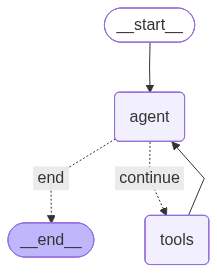

In [56]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
def print_stream(stream):
    """Helper function for formatting the stream nicely."""
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

inputs = {"messages": [HumanMessage(content="What's the weather like in siraha nepal, and what should I wear based on the temperature?")]}

print_stream(graph.stream(inputs, stream_mode="values"))

In [60]:
def chatbot_response(message, history):
    inputs = {
        "messages": [HumanMessage(content=message)]
    }

    response = ""

    for s in graph.stream(inputs, stream_mode="values"):
        msg = s["messages"][-1]

        if hasattr(msg, "content"):
            response = msg.content
            yield response

In [62]:
import gradio as gr

demo = gr.ChatInterface(
    fn=chatbot_response
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
